# Benchmarking with Takou's Naive & Heuristic-1 (Random Graph Dataset)

For every graph in the random dataset and each of the 5 orderings (random + 4 algorithms),
this notebook calls Takou's MATLAB ([see here for their repository](https://github.com/eva-takou/Optimal_Generation_Photonic_Graphs_Public/tree/main?tab=readme-ov-file)) to compute emitters and CNOTs via two methods:
**Naive** and **Heuristic-1**.

**Goals:**
1. **Validation** — Our Python emitter count must match Takou's Naive emitter count for the same ordering (both solve the same problem. Takou additionally optimises CNOTs).
2. **CNOT analysis** — Do orderings that minimise emitters also tend to reduce CNOTs? We compare Takou's Naive and Heuristic-1 CNOT counts across orderings found by emitter-minimising algorithms.

In [ ]:
import json
import subprocess
import tempfile
import pathlib
import numpy as np
import scipy.io
import networkx as nx

# ── Configuration ───────────────────────────────────────────────────────────
MATLAB_PROJECT = pathlib.Path(
    "/Users/konstantinosrafailrevis/Documents/MATLAB"
    "/Optimal_Generation_Photonic_Graphs_Public"
)
MATLAB_BIN = "/Applications/MATLAB_R2025a.app/bin/matlab"


def run_takou_matlab(
    graph: nx.Graph,
    ordering: list[int],
) -> dict:
    """
    Run Takou's Naive and Heuristic-1 algorithms on *graph* with the given
    *ordering* (0-based Python node labels).

    Returns
    -------
    dict with keys:
        naive_cnots, naive_emitters, heu1_cnots, heu1_emitters
    """
    # Build adjacency matrix with rows/cols following the ordering
    adj = nx.adjacency_matrix(graph, nodelist=ordering).toarray().astype(np.float64)

    # MATLAB expects 1-based ordering: 1, 2, ..., n
    matlab_ordering = np.arange(1, len(ordering) + 1, dtype=np.float64)

    with tempfile.TemporaryDirectory() as tmpdir:
        mat_in  = str(pathlib.Path(tmpdir) / "input.mat")
        json_out = str(pathlib.Path(tmpdir) / "output.json")

        # Save input for MATLAB
        scipy.io.savemat(mat_in, {"Adj": adj, "ordering": matlab_ordering})

        # Call MATLAB
        cmd = (
            f"addpath(genpath('{MATLAB_PROJECT}'));"
            f" run_from_python('{mat_in}','{json_out}');"
        )
        result = subprocess.run(
            [MATLAB_BIN, "-batch", cmd],
            capture_output=True, text=True, timeout=300,
        )
        if result.returncode != 0:
            raise RuntimeError(
                f"MATLAB failed (rc={result.returncode}):\n"
                f"stdout: {result.stdout}\nstderr: {result.stderr}"
            )

        with open(json_out) as f:
            return json.load(f)

run_takou_matlab() ready.


## Demo — Small test graph

Build a small graph, pick a trivial ordering, and verify that the MATLAB bridge returns valid results.

In [4]:
# ── Quick demo with a small star graph ───────────────────────────────────
g = nx.star_graph(4)  # 5 nodes: 0 is center, 1-4 are leaves
ordering = list(range(g.number_of_nodes()))  # [0, 1, 2, 3, 4]

print(f"Graph: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")
print(f"Ordering (0-based): {ordering}")

results = run_takou_matlab(g, ordering)
print(f"\nNaive  → emitters: {results['naive_emitters']}, CNOTs: {results['naive_cnots']}")
print(f"Heur-1 → emitters: {results['heu1_emitters']}, CNOTs: {results['heu1_cnots']}")

Graph: 5 nodes, 4 edges
Ordering (0-based): [0, 1, 2, 3, 4]

Naive  → emitters: 1, CNOTs: 0
Heur-1 → emitters: 1, CNOTs: 0


## Load random-graph dataset and all algorithm orderings

Reads the 5 CSVs produced by the batch processing scripts.  Each row is one graph instance with the ordering and metrics from one algorithm.

In [5]:
import os, ast, pickle
import pandas as pd

BASE = '/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/photonic-graphstate-generator-main'

df_random = pd.read_csv(os.path.join(BASE, 'graph_stats_random.csv'))
df_path   = pd.read_csv(os.path.join(BASE, 'graph_stats_path_clustering.csv'))
df_rw     = pd.read_csv(os.path.join(BASE, 'graph_stats_rank_width.csv'))
df_rw_sa  = pd.read_csv(os.path.join(BASE, 'graph_stats_rank_width_sa.csv'))
df_sam    = pd.read_csv(os.path.join(BASE, 'graph_stats_saminla.csv'))

# ── Ordering sources: (label, df, suffix, ordering_column) ──────────
SOURCES = [
    ("Random",          df_random, "random",  "ordering_random"),
    ("Path Clustering", df_path,   "path",    "ordering_path"),
    ("Rank Width",      df_rw,     "rw",      "ordering_rw"),
    ("Rank Width SA",   df_rw_sa,  "rw_sa",   "sa_ordering_rw_sa"),
    ("SAminLA",         df_sam,    "saminla",  "ordering_saminla"),
]

# ── Merge all orderings + our emitters/CNOTs into one frame ─────────
key_cols = ['path', 'node_number', 'p']
merged = df_random[key_cols].copy()
for label, df_algo, sfx, ord_col in SOURCES:
    em_col  = f'num_emitters_{sfx}'
    cn_col  = f'num_emitter_CNOTs_{sfx}'
    gt_col  = f'num_gates_{sfx}'
    merged = merged.merge(
        df_algo[['path', ord_col, em_col, cn_col, gt_col]],
        on='path', how='inner',
    )

merged['node_number'] = pd.to_numeric(merged['node_number'], errors='coerce').astype(int)
merged['p'] = pd.to_numeric(merged['p'], errors='coerce')

print(f"Merged dataset: {len(merged)} graphs × {merged.shape[1]} columns")
print(f"Node range: {merged['node_number'].min()}–{merged['node_number'].max()}")
merged.head(3)

Merged dataset: 3000 graphs × 23 columns
Node range: 6–30


,path,node_number,p,ordering_random,num_emitters_random,num_emitter_CNOTs_random,num_gates_random,ordering_path,num_emitters_path,num_emitter_CNOTs_path,...,num_emitter_CNOTs_rw,num_gates_rw,sa_ordering_rw_sa,num_emitters_rw_sa,num_emitter_CNOTs_rw_sa,num_gates_rw_sa,ordering_saminla,num_emitters_saminla,num_emitter_CNOTs_saminla,num_gates_saminla
0,./random_graph_db/graph_db_node_10/01_p0.1/01_...,10,0.1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",3,3,21,"[8, 6, 0, 9, 5, 4, 3, 2, 7, 1]",1,0,...,0,11,"[8, 6, 0, 9, 5, 4, 3, 2, 7, 1]",1,0,11,"[8, 6, 9, 0, 5, 4, 3, 2, 7, 1]",1,0,11
1,./random_graph_db/graph_db_node_10/01_p0.1/01_...,10,0.1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",4,4,20,"[7, 1, 9, 5, 0, 3, 2, 6, 8, 4]",1,0,...,0,11,"[7, 1, 9, 5, 0, 3, 2, 6, 8, 4]",1,0,11,"[7, 1, 9, 5, 0, 2, 3, 6, 8, 4]",1,0,11
2,./random_graph_db/graph_db_node_10/01_p0.1/01_...,10,0.1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",5,7,26,"[6, 2, 1, 9, 0, 5, 8, 7, 4, 3]",2,3,...,2,16,"[4, 8, 3, 5, 7, 0, 9, 1, 6, 2]",2,2,16,"[3, 4, 8, 7, 5, 0, 9, 1, 6, 2]",2,2,16


## Batch MATLAB processing

For each graph times ordering combination, call Takou's Naive and Heuristic-1.
Uses a **batch MATLAB script** to avoid per-call MATLAB startup overhead —
all graphs in one chunk are processed in a single MATLAB session.

Results are checkpointed to `takou_results/takou_random_graphs.pkl` so
re-running skips already-completed work.

In [6]:
import time

CHECKPOINT_DIR = pathlib.Path("takou_results")
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_FILE = CHECKPOINT_DIR / "takou_random_graphs.pkl"

# ── Batch helper: process many (graph, ordering) pairs in one MATLAB call ──
def run_takou_batch(jobs: list[dict], batch_size: int = 200) -> list[dict]:
    """
    jobs: list of dicts with keys 'graph_path', 'ordering', 'job_id'.
    Returns list of dicts with keys 'job_id', 'naive_cnots', 'naive_emitters',
                                     'heu1_cnots', 'heu1_emitters'.
    Processes in chunks of batch_size to keep temp dirs manageable.
    """
    all_results = []
    for chunk_start in range(0, len(jobs), batch_size):
        chunk = jobs[chunk_start : chunk_start + batch_size]

        with tempfile.TemporaryDirectory() as tmpdir:
            tmp = pathlib.Path(tmpdir)

            # Write one .mat per job
            for i, job in enumerate(chunk):
                graph_file = job['graph_path']
                ordering = job['ordering']

                # Load graph
                with open(graph_file, 'rb') as f:
                    g = pickle.load(f)

                adj = nx.adjacency_matrix(g, nodelist=ordering).toarray().astype(np.float64)
                matlab_ordering = np.arange(1, len(ordering) + 1, dtype=np.float64)
                scipy.io.savemat(
                    str(tmp / f"input_{i+1:05d}.mat"),
                    {"Adj": adj, "ordering": matlab_ordering},
                )

            json_out = str(tmp / "results.json")

            cmd = (
                f"addpath(genpath('{MATLAB_PROJECT}'));"
                f" run_batch_from_python('{tmpdir}','{json_out}');"
            )
            t0 = time.perf_counter()
            result = subprocess.run(
                [MATLAB_BIN, "-batch", cmd],
                capture_output=True, text=True, timeout=3600,
            )
            elapsed = time.perf_counter() - t0

            if result.returncode != 0:
                print(f"MATLAB ERROR (chunk {chunk_start}):\n{result.stderr[:500]}")
                raise RuntimeError(f"MATLAB failed (rc={result.returncode})")

            with open(json_out) as f:
                matlab_results = json.load(f)

            # Map back by index
            idx_map = {r['idx']: r for r in matlab_results}
            for i, job in enumerate(chunk):
                mr = idx_map[i + 1]
                all_results.append({
                    'job_id':          job['job_id'],
                    'naive_cnots':     mr['naive_cnots'],
                    'naive_emitters':  mr['naive_emitters'],
                    'heu1_cnots':      mr['heu1_cnots'],
                    'heu1_emitters':   mr['heu1_emitters'],
                })

            print(f"  Chunk {chunk_start}–{chunk_start+len(chunk)-1}: "
                  f"{len(chunk)} jobs in {elapsed:.1f}s "
                  f"({elapsed/len(chunk):.2f}s/job)")

    return all_results


print(f"Batch helper ready.  Checkpoint: {CHECKPOINT_FILE}")

Batch helper ready.  Checkpoint: takou_results/takou_random_graphs.pkl


In [ ]:
# ── Build job list and run (with checkpoint) ──────────────────────────────────

# Load checkpoint if exists
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, 'rb') as f:
        completed = pickle.load(f)  # dict: job_id -> result dict
    print(f"Loaded checkpoint: {len(completed)} jobs already done.")
else:
    completed = {}

# Build job list for all (graph × ordering) combinations
jobs_todo = []
for row_idx, row in merged.iterrows():
    graph_file = row['path']
    # Make path absolute if relative
    if graph_file.startswith('./'):
        graph_file = os.path.join(BASE, graph_file[2:])
    elif not os.path.isabs(graph_file):
        graph_file = os.path.join(BASE, graph_file)

    for label, _, sfx, ord_col in SOURCES:
        job_id = f"{row['path']}|{sfx}"

        if job_id in completed:
            continue

        ordering_str = row[ord_col]
        ordering = ast.literal_eval(ordering_str) if isinstance(ordering_str, str) else list(ordering_str)

        jobs_todo.append({
            'job_id':     job_id,
            'graph_path': graph_file,
            'ordering':   ordering,
        })

print(f"Total jobs: {len(merged) * len(SOURCES)},  "
      f"already done: {len(completed)},  "
      f"remaining: {len(jobs_todo)}")

if jobs_todo:
    print(f"\nStarting batch processing ({len(jobs_todo)} jobs)...")
    new_results = run_takou_batch(jobs_todo, batch_size=200)

    for r in new_results:
        completed[r['job_id']] = r

    # Save checkpoint
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(completed, f)
    print(f"\nCheckpoint saved: {len(completed)} total results.")
else:
    print("All jobs already completed!")

Total jobs: 15000,  already done: 0,  remaining: 15000

Starting batch processing (15000 jobs)...
  Chunk 0–199: 200 jobs in 9.4s (0.05s/job)
  Chunk 200–399: 200 jobs in 10.4s (0.05s/job)
  Chunk 400–599: 200 jobs in 9.8s (0.05s/job)
  Chunk 600–799: 200 jobs in 10.0s (0.05s/job)
  Chunk 800–999: 200 jobs in 12.7s (0.06s/job)
  Chunk 1000–1199: 200 jobs in 10.9s (0.05s/job)
  Chunk 1200–1399: 200 jobs in 10.1s (0.05s/job)
  Chunk 1400–1599: 200 jobs in 15.2s (0.08s/job)
  Chunk 1600–1799: 200 jobs in 14.2s (0.07s/job)
  Chunk 1800–1999: 200 jobs in 12.1s (0.06s/job)
  Chunk 2000–2199: 200 jobs in 17.8s (0.09s/job)
  Chunk 2200–2399: 200 jobs in 14.5s (0.07s/job)
  Chunk 2400–2599: 200 jobs in 14.4s (0.07s/job)
  Chunk 2600–2799: 200 jobs in 18.4s (0.09s/job)
  Chunk 2800–2999: 200 jobs in 15.6s (0.08s/job)
  Chunk 3000–3199: 200 jobs in 14.3s (0.07s/job)
  Chunk 3200–3399: 200 jobs in 21.3s (0.11s/job)
  Chunk 3400–3599: 200 jobs in 18.8s (0.09s/job)
  Chunk 3600–3799: 200 jobs in 16.

In [8]:
# ── Assemble Takou results into the merged DataFrame ─────────────────────
for label, _, sfx, _ in SOURCES:
    merged[f'takou_naive_em_{sfx}']    = np.nan
    merged[f'takou_naive_cnots_{sfx}'] = np.nan
    merged[f'takou_heu1_em_{sfx}']     = np.nan
    merged[f'takou_heu1_cnots_{sfx}']  = np.nan

for row_idx, row in merged.iterrows():
    for label, _, sfx, _ in SOURCES:
        job_id = f"{row['path']}|{sfx}"
        if job_id in completed:
            r = completed[job_id]
            merged.at[row_idx, f'takou_naive_em_{sfx}']    = r['naive_emitters']
            merged.at[row_idx, f'takou_naive_cnots_{sfx}'] = r['naive_cnots']
            merged.at[row_idx, f'takou_heu1_em_{sfx}']     = r['heu1_emitters']
            merged.at[row_idx, f'takou_heu1_cnots_{sfx}']  = r['heu1_cnots']

n_filled = merged[f'takou_naive_em_random'].notna().sum()
print(f"Takou results attached: {n_filled} / {len(merged)} graphs have data.")
merged.head(3)

Takou results attached: 3000 / 3000 graphs have data.


,path,node_number,p,ordering_random,num_emitters_random,num_emitter_CNOTs_random,num_gates_random,ordering_path,num_emitters_path,num_emitter_CNOTs_path,...,takou_heu1_em_rw,takou_heu1_cnots_rw,takou_naive_em_rw_sa,takou_naive_cnots_rw_sa,takou_heu1_em_rw_sa,takou_heu1_cnots_rw_sa,takou_naive_em_saminla,takou_naive_cnots_saminla,takou_heu1_em_saminla,takou_heu1_cnots_saminla
0,./random_graph_db/graph_db_node_10/01_p0.1/01_...,10,0.1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",3,3,21,"[8, 6, 0, 9, 5, 4, 3, 2, 7, 1]",1,0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,./random_graph_db/graph_db_node_10/01_p0.1/01_...,10,0.1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",4,4,20,"[7, 1, 9, 5, 0, 3, 2, 6, 8, 4]",1,0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,./random_graph_db/graph_db_node_10/01_p0.1/01_...,10,0.1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",5,7,26,"[6, 2, 1, 9, 0, 5, 8, 7, 4, 3]",2,3,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


## Validation: Our emitters vs Takou's Naive emitters

For the same graph and ordering, the number of emitters must be identical — both our Python code and Takou's MATLAB Naive method solve the emission ordering problem. Any mismatch indicates a bug.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

ALGO_LABELS  = ['Random','Path Clustering', 'Rank Width', 'Rank Width SA', 'SAminLA']
ALGO_SUFFIXES = ['random','path', 'rw', 'rw_sa', 'saminla']
ALGO_COLORS   = ['#607D8B', '#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

# ── Check emitter agreement for each ordering source ────────────────
print("=== Emitter Validation: Our code vs Takou Naive ===\n")
all_match = True
for label, sfx in zip(ALGO_LABELS, ALGO_SUFFIXES):
    our_col   = f'num_emitters_{sfx}'
    takou_col = f'takou_naive_em_{sfx}'
    valid = merged[[our_col, takou_col]].dropna()
    if valid.empty:
        print(f"  {label:20s}: no data yet")
        continue
    mismatches = (valid[our_col] != valid[takou_col]).sum()
    total = len(valid)
    if mismatches == 0:
        print(f"  {label:20s}: {total:4d} graphs — ALL MATCH ")
    else:
        all_match = False
        print(f"  {label:20s}: {total:4d} graphs — {mismatches} MISMATCHES ")
        bad = valid[valid[our_col] != valid[takou_col]]
        print(f"    Sample mismatches:\n{bad.head(5)}")

if all_match:
    print("\n Pipeline validated: emitter counts are consistent across both codebases.")

=== Emitter Validation: Our code vs Takou Naive ===

  Random              : 3000 graphs — ALL MATCH ✓
  Path Clustering     : 3000 graphs — ALL MATCH ✓
  Rank Width          : 3000 graphs — ALL MATCH ✓
  Rank Width SA       : 3000 graphs — ALL MATCH ✓
  SAminLA             : 3000 graphs — ALL MATCH ✓

✓ Pipeline validated: emitter counts are consistent across both codebases.


## Analysis: Emitters & CNOTs across orderings

For each graph we have 5 orderings (random + 4 algorithms). For each ordering, Takou gives:
- **Naive**: emitters + CNOTs (given the ordering, no gate optimisation beyond reordering)
- **Heuristic-1**: same emitters but potentially fewer CNOTs (CNOT-aware gate optimisation)

We compare:
1. **Emitters** — how our algorithms' orderings reduce emitters vs random ordering
2. **Naive CNOTs** — how CNOTs change across orderings (before gate optimisation)
3. **Heu1 CNOTs** — how CNOTs change with Takou's gate optimisation applied on top

**Key question:** does minimising emitters also minimise CNOTs, or is there a trade-off?

In [19]:
# ── Compute % difference vs random ordering for Takou metrics ────────────
# Metrics to analyse: (column_template, display_label)
TAKOU_METRICS = [
    ('takou_naive_em_{}',    'Emitters (Naive)'),
    ('takou_naive_cnots_{}', 'CNOTs (Naive)'),
    ('takou_heu1_em_{}',     'Emitters (Heu-1)'),
    ('takou_heu1_cnots_{}',  'CNOTs (Heu-1)'),
]

# Only the 4 optimisation algorithms (not random itself)
OPT_LABELS   = ALGO_LABELS[1:]    # ['Path Clustering', 'Rank Width', 'Rank Width SA', 'SAminLA']
OPT_SUFFIXES = ALGO_SUFFIXES[1:]  # ['path', 'rw', 'rw_sa', 'saminla']
OPT_COLORS   = ALGO_COLORS[1:]    # blue, orange, purple, green

for col_tmpl, _ in TAKOU_METRICS:
    rnd_col = col_tmpl.format('random')
    denom = merged[rnd_col].replace(0, np.nan)
    for sfx in OPT_SUFFIXES:
        algo_col = col_tmpl.format(sfx)
        merged[f'pct_{col_tmpl.format(sfx)}'] = (
            (merged[algo_col] - merged[rnd_col]) / denom * 100.0
        )

print("% difference columns created.")
print("Sample columns:", [c for c in merged.columns if c.startswith('pct_takou')][:8])

% difference columns created.
Sample columns: ['pct_takou_naive_em_path', 'pct_takou_naive_em_rw', 'pct_takou_naive_em_rw_sa', 'pct_takou_naive_em_saminla', 'pct_takou_naive_cnots_path', 'pct_takou_naive_cnots_rw', 'pct_takou_naive_cnots_rw_sa', 'pct_takou_naive_cnots_saminla']


### Plot A — Mean % Difference vs Random Ordering

Each of the four subplots corresponds to one Takou metric: **Emitters (Naive)**, **CNOTs (Naive)**, **Emitters (Heu-1)**, and **CNOTs (Heu-1)**. Within every subplot, each bar represents one of the four emitter-minimising algorithms (Path Clustering, Rank Width, Rank Width SA, SAminLA).

**How to read it:**
- **Bar height** = mean percentage change compared to the random ordering across all 3 000 graphs. A negative bar means the algorithm's ordering uses *fewer* resources than random on average.
- **Error bars** = ± 1 standard error of the mean (SEM), showing the precision of the estimate.
- **White diamond** = the median % change (robust to outliers — if it differs noticeably from the bar it signals skewness).
- **Dashed line at 0 %** = the random baseline. Bars below it indicate an improvement.

Since the Naive method preserves the number of emitters by construction, the first and third subplots (Emitters) act as a sanity check: they should agree with our earlier Python-only results. The second and fourth subplots (CNOTs) reveal whether orderings that minimise emitters also reduce the gate count.

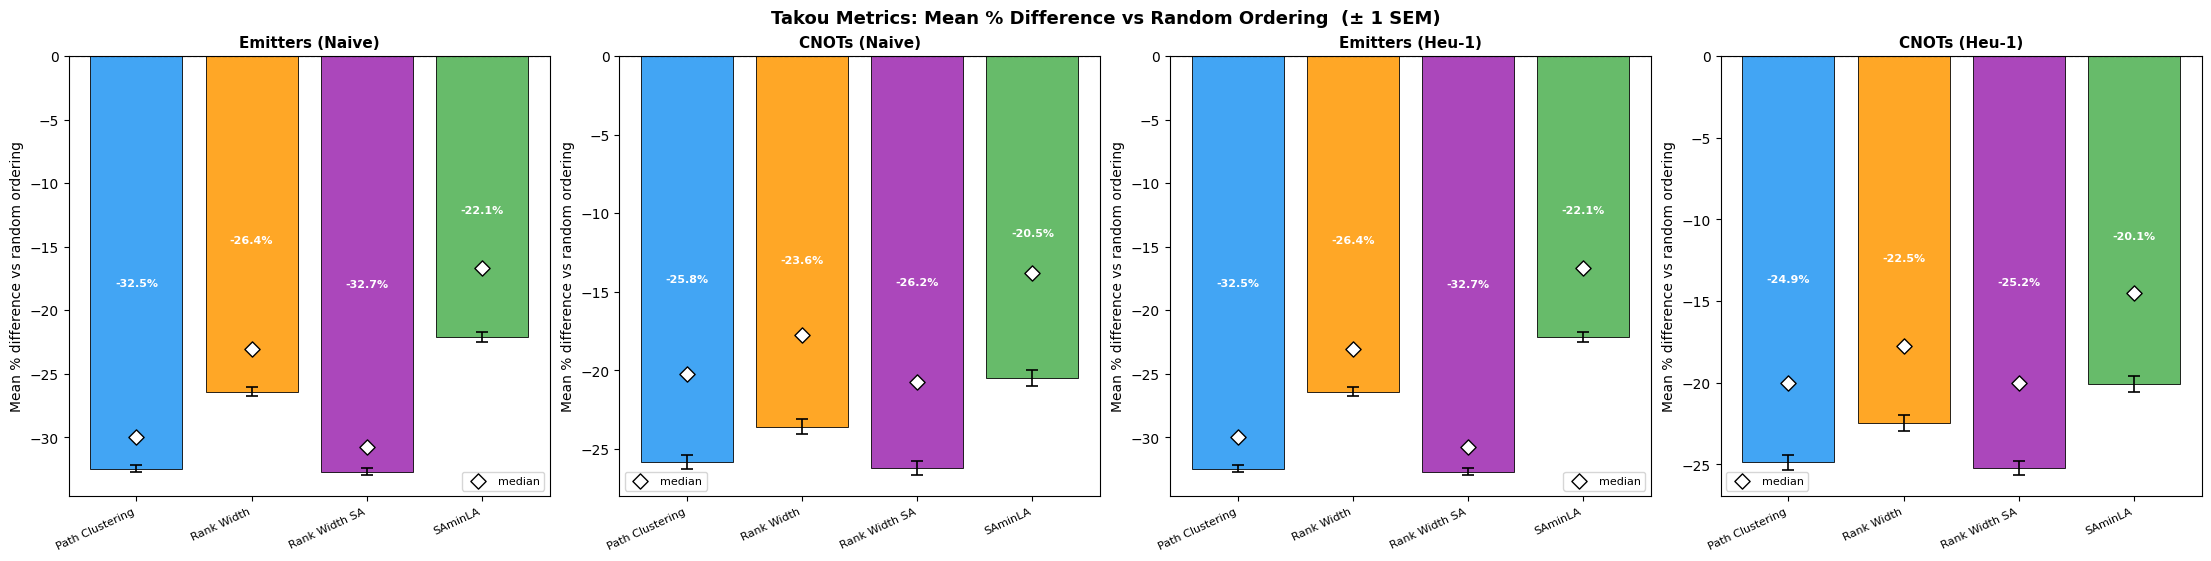

In [20]:
# ═══════════════════════════════════════════════════════════════════
# PLOT A — Mean % difference vs random ordering (Takou metrics)
# ═══════════════════════════════════════════════════════════════════
n_metrics = len(TAKOU_METRICS)
fig, axes = plt.subplots(1, n_metrics, figsize=(5.5 * n_metrics, 5.5),
                         constrained_layout=True)

for ax, (col_tmpl, m_label) in zip(axes, TAKOU_METRICS):
    means, sems, medians = [], [], []
    for sfx in OPT_SUFFIXES:
        pct_col = f'pct_{col_tmpl.format(sfx)}'
        means.append(merged[pct_col].mean())
        sems.append(merged[pct_col].sem())
        medians.append(merged[pct_col].median())

    x = np.arange(len(OPT_LABELS))
    bars = ax.bar(x, means, yerr=sems, capsize=4,
                  error_kw=dict(elinewidth=1.2, capthick=1.2),
                  color=OPT_COLORS, edgecolor='black', linewidth=0.7, alpha=0.85)

    ax.scatter(x, medians, color='white', edgecolors='black',
               zorder=5, s=60, marker='D', label='median')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(OPT_LABELS, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Mean % difference vs random ordering')
    ax.set_title(m_label, fontsize=11, fontweight='bold')

    for bar, mv in zip(bars, means):
        label_y = mv * 0.55
        ax.text(bar.get_x() + bar.get_width() / 2, label_y,
                f'{mv:.1f}%', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    ax.legend(fontsize=8)

fig.suptitle('Takou Metrics: Mean % Difference vs Random Ordering  (± 1 SEM)',
             fontsize=13, fontweight='bold')
plt.show()

### Plot B — Win Rate & Distribution of % Differences

This figure has two rows, each with four subplots (one per Takou metric).

**Top row — Win-rate bars:**
- Each coloured bar shows the **percentage of graphs** for which the algorithm's ordering yields a *strictly lower* value than the random ordering. The grey segment on top is the tie rate (algorithm equals random).
- The red dashed line at 50 % marks the break-even point. An algorithm above this line beats random on the majority of instances.
- High win rates in the CNOT columns (while emitter win rates are also high) suggest that emitter-minimising orderings tend to help CNOTs as well.

**Bottom row — Box-plots:**
- Each box shows the **full distribution** of the per-graph % difference vs random. The notch indicates a 95 % confidence interval around the median.
- A box sitting entirely below 0 means the algorithm is almost always better than random.
- Outliers (dots above/below the whiskers) reveal graphs where the ordering performs unusually well or poorly.
- Comparing box widths across metrics tells you whether CNOT improvements are as consistent as emitter improvements.

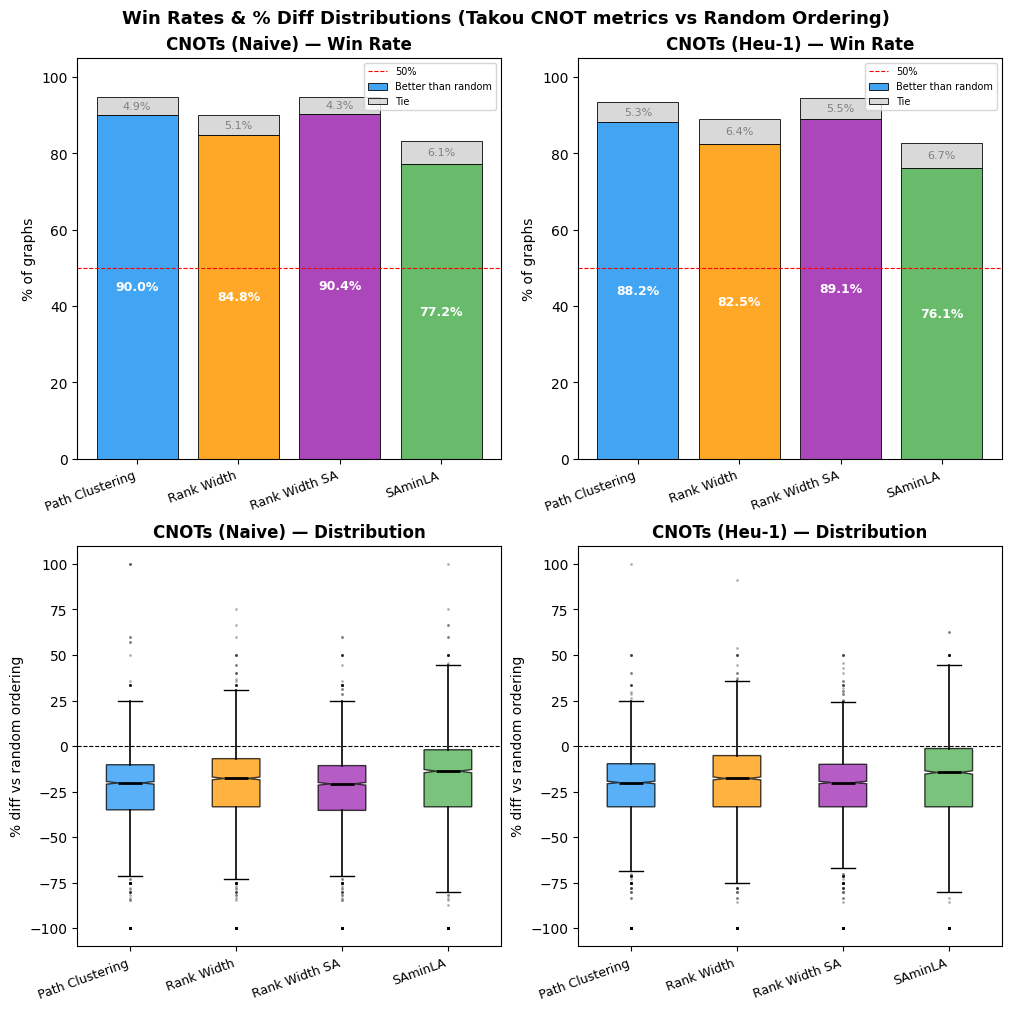

In [29]:
# ═══════════════════════════════════════════════════════════════════
# PLOT B — Win-rate & distribution of % differences (Takou CNOT metrics)
# ═══════════════════════════════════════════════════════════════════
CNOT_METRICS = [(t, l) for t, l in TAKOU_METRICS if 'cnots' in t]
n_cnot = len(CNOT_METRICS)
fig, axes = plt.subplots(2, n_cnot, figsize=(5 * n_cnot, 10),
                         constrained_layout=True)
if n_cnot == 1:
    axes = axes.reshape(2, 1)

for col_idx, (col_tmpl, m_label) in enumerate(CNOT_METRICS):
    rnd_col = col_tmpl.format('random')

    # ── top row: win-rate bar ────────────────────────────────────────
    ax_top = axes[0, col_idx]
    win_rates, tie_rates = [], []
    for sfx in OPT_SUFFIXES:
        algo_col = col_tmpl.format(sfx)
        valid = merged[[algo_col, rnd_col]].dropna()
        win_rates.append((valid[algo_col] < valid[rnd_col]).mean() * 100)
        tie_rates.append((valid[algo_col] == valid[rnd_col]).mean() * 100)

    x = np.arange(len(OPT_LABELS))
    wa, ta = np.array(win_rates), np.array(tie_rates)
    ax_top.bar(x, wa, color=OPT_COLORS, edgecolor='black',
               linewidth=0.7, alpha=0.85, label='Better than random')
    ax_top.bar(x, ta, bottom=wa, color='lightgrey',
               edgecolor='black', linewidth=0.7, alpha=0.85, label='Tie')

    for xi, (w, t) in enumerate(zip(wa, ta)):
        ax_top.text(xi, w / 2, f'{w:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        if t > 0.5:
            ax_top.text(xi, w + t / 2, f'{t:.1f}%', ha='center', va='center',
                        fontsize=8, color='grey')

    ax_top.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
    ax_top.set_ylim(0, 105)
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(OPT_LABELS, rotation=20, ha='right', fontsize=9)
    ax_top.set_ylabel('% of graphs')
    ax_top.set_title(f'{m_label} — Win Rate', fontweight='bold')
    ax_top.legend(fontsize=7)

    # ── bottom row: box-plots ────────────────────────────────────────
    ax_bot = axes[1, col_idx]
    data = [merged[f'pct_{col_tmpl.format(sfx)}'].dropna().values
            for sfx in OPT_SUFFIXES]
    bp = ax_bot.boxplot(data, patch_artist=True, notch=True,
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], OPT_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax_bot.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax_bot.set_xticks(range(1, len(OPT_LABELS) + 1))
    ax_bot.set_xticklabels(OPT_LABELS, rotation=20, ha='right', fontsize=9)
    ax_bot.set_ylabel('% diff vs random ordering')
    ax_bot.set_title(f'{m_label} — Distribution', fontweight='bold')

fig.suptitle('Win Rates & % Diff Distributions (Takou CNOT metrics vs Random Ordering)',
             fontsize=13, fontweight='bold')
plt.show()

### Plot C — Mean % Improvement vs Graph Size

Two subplots (one per metric), where each line represents an algorithm. The x-axis is the number of nodes (6–30) and the y-axis is the mean % difference vs random ordering at that node count.

**How to read it:**
- A line that **stays negative and trends downward** means the algorithm's advantage grows with graph size — a desirable scaling property.
- A line that **rises toward 0** or turns positive indicates the algorithm loses its edge on larger graphs.
- The **shaded band** around each line is ± 1 SEM. Where bands overlap, the algorithms are not significantly different at that node count.

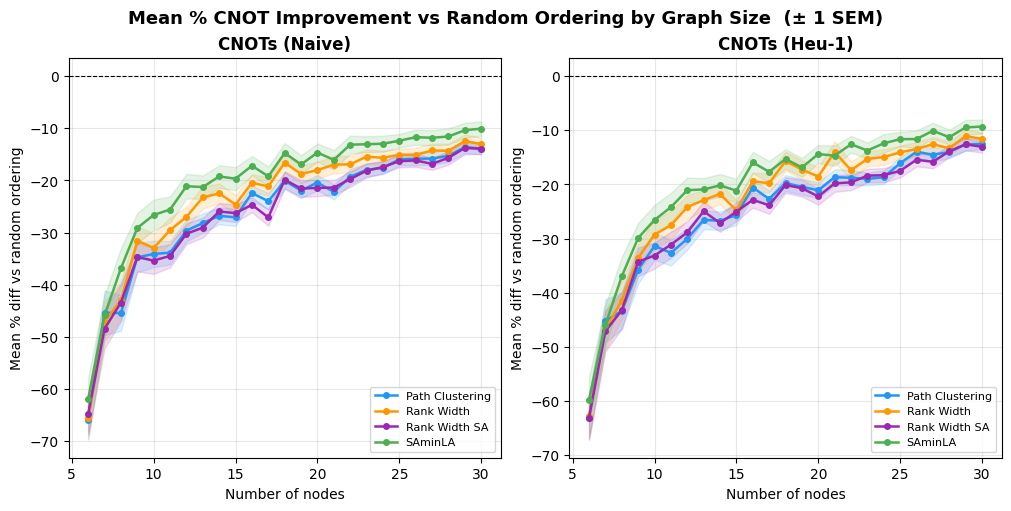

In [30]:
# ═══════════════════════════════════════════════════════════════════
# PLOT C — Mean % improvement vs graph size (Takou CNOT metrics)
# ═══════════════════════════════════════════════════════════════════
CNOT_METRICS_C = [(t, l) for t, l in TAKOU_METRICS if 'cnots' in t]
n_cnot_c = len(CNOT_METRICS_C)
fig, axes = plt.subplots(1, n_cnot_c, figsize=(5 * n_cnot_c, 5),
                         constrained_layout=True, sharey=False)
if n_cnot_c == 1:
    axes = [axes]

for ax, (col_tmpl, m_label) in zip(axes, CNOT_METRICS_C):
    for sfx, label, color in zip(OPT_SUFFIXES, OPT_LABELS, OPT_COLORS):
        pct_col = f'pct_{col_tmpl.format(sfx)}'
        grp = merged.groupby('node_number')[pct_col].agg(['mean', 'sem']).reset_index()
        ax.plot(grp['node_number'], grp['mean'], marker='o', markersize=4,
                label=label, color=color, linewidth=1.8)
        ax.fill_between(grp['node_number'],
                        grp['mean'] - grp['sem'],
                        grp['mean'] + grp['sem'],
                        alpha=0.15, color=color)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Mean % diff vs random ordering')
    ax.set_title(m_label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Mean % CNOT Improvement vs Random Ordering by Graph Size  (± 1 SEM)',
             fontsize=13, fontweight='bold')
plt.show()

### Plot D — Head-to-Head: Best Ordering per Graph

Unlike Plots A–C (which compare each algorithm to random), this plot compares **all five orderings against each other** — including random. For every graph, we pick the ordering that achieves the *lowest* value for each metric, and the bar shows how often each ordering wins.

**How to read it:**
- A tall bar means that ordering is the single best choice on a large fraction of graphs.
- If **Random** has a non-negligible bar in the CNOT panels but almost none in the Emitters panels, it means some orderings that are poor for emitters happen to produce fewer CNOTs — evidence of a trade-off.
- When one algorithm dominates both the emitter and CNOT panels, it suggests the two objectives are well-aligned for that algorithm.
- Ties are broken arbitrarily (leftmost column wins in `argmin`), so very close contests may slightly favour the first entry.

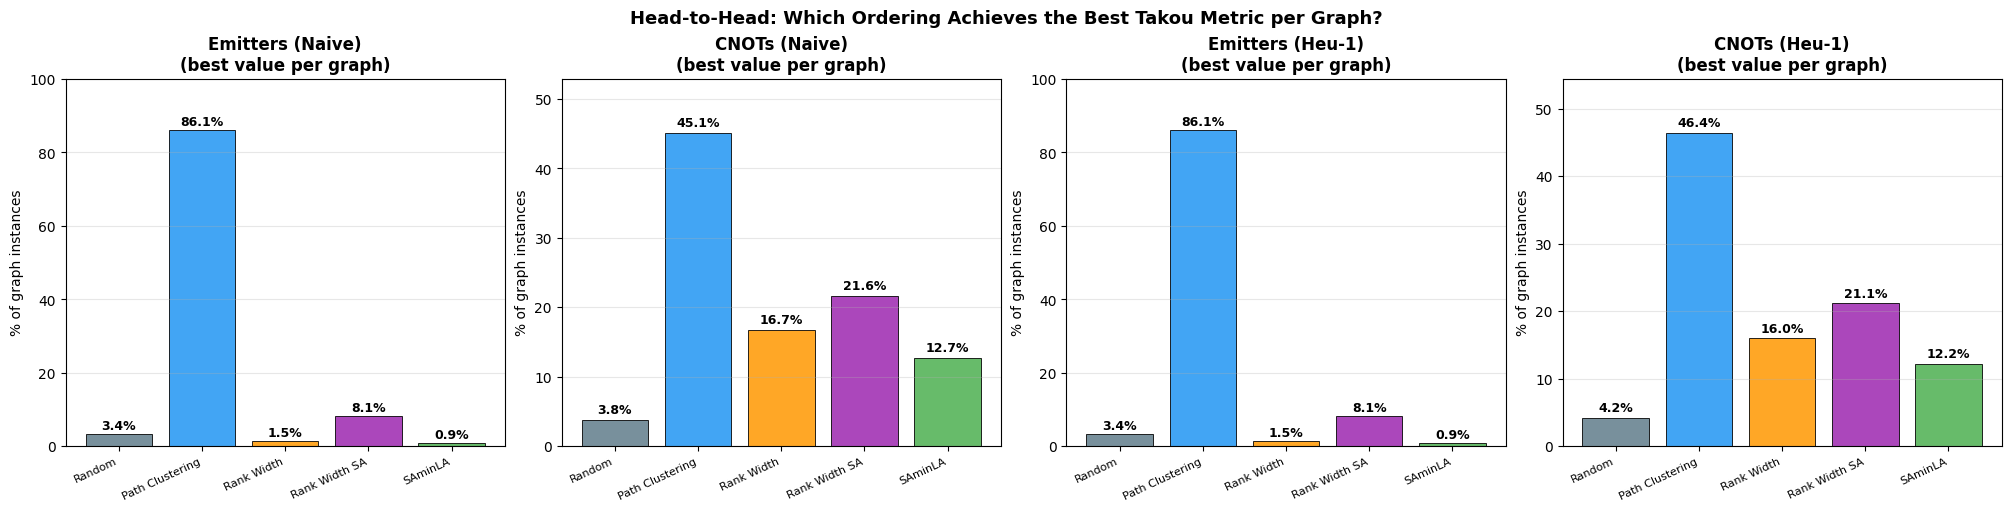

In [23]:
# ═══════════════════════════════════════════════════════════════════
# PLOT D — Head-to-head: which algorithm's ordering achieves the
#           best (lowest) value per graph for each Takou metric
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5),
                         constrained_layout=True)

for ax, (col_tmpl, m_label) in zip(axes, TAKOU_METRICS):
    # Columns for all 5 orderings (including random)
    all_cols = [col_tmpl.format(sfx) for sfx in ALGO_SUFFIXES]
    valid = merged[all_cols].dropna()
    best_idx = valid.values.argmin(axis=1)

    counts = np.bincount(best_idx, minlength=len(ALGO_LABELS))
    pcts = counts / counts.sum() * 100

    bars = ax.bar(ALGO_LABELS, pcts, color=ALGO_COLORS,
                  edgecolor='black', linewidth=0.7, alpha=0.85)
    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5, f'{pct:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylim(0, max(pcts) * 1.15 + 1)
    ax.set_xticks(range(len(ALGO_LABELS)))
    ax.set_xticklabels(ALGO_LABELS, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('% of graph instances')
    ax.set_title(f'{m_label}\n(best value per graph)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Head-to-Head: Which Ordering Achieves the Best Takou Metric per Graph?',
             fontsize=13, fontweight='bold')
plt.show()

### Plot E — Radar Chart & Summary Table

The radar chart provides a **single visual snapshot** of how the four algorithms rank across all four Takou metrics simultaneously.

**How to read the radar:**
- Each axis corresponds to one metric (Emitters Naive, CNOTs Naive, Emitters Heu-1, CNOTs Heu-1). Values are **normalised to 0–100** per axis where 100 = best algorithm on that metric and 0 = worst.
- A polygon that covers a larger area indicates an algorithm that performs well across all metrics.
- If an algorithm's polygon extends far on the Emitters axes but shrinks on the CNOTs axes (or vice-versa), there is a disconnect between emitter and CNOT optimisation for that strategy.

**Summary table (printed below the chart):**
- Shows the raw mean % change vs random for every (algorithm × metric) pair.
- Negative values = improvement over random. The more negative, the better.
- Cross-reading a row tells you how balanced an algorithm is. cross-reading a column tells you which algorithm is best for that specific metric.

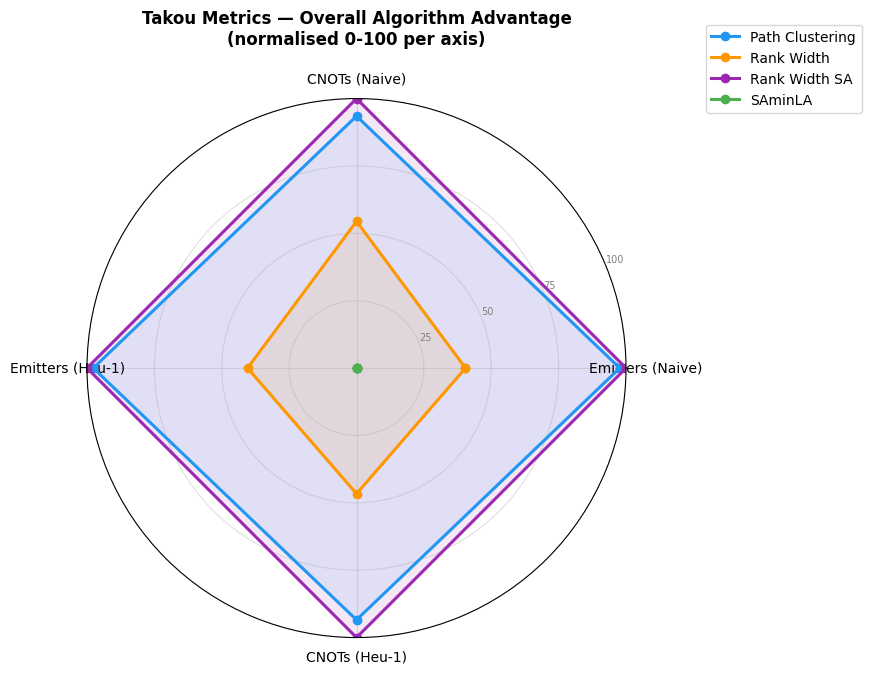


── SUMMARY: mean % change vs random ordering (Takou metrics) ──
Algorithm                   Emitters (Naive)         CNOTs (Naive)      Emitters (Heu-1)         CNOTs (Heu-1)
--------------------------------------------------------------------------------------------------------------
Path Clustering                      -32.46%               -25.84%               -32.46%               -24.88%
Rank Width                           -26.39%               -23.59%               -26.39%               -22.47%
Rank Width SA                        -32.70%               -26.21%               -32.70%               -25.22%
SAminLA                              -22.11%               -20.46%               -22.11%               -20.07%

  Negative = algorithm ordering uses fewer resources than random ordering.


In [31]:
# ═══════════════════════════════════════════════════════════════════
# PLOT E — Radar chart: overall algorithm ranking across Takou metrics
#           + summary table
# ═══════════════════════════════════════════════════════════════════
metric_labels_radar = [ml for _, ml in TAKOU_METRICS]
n_axes = len(metric_labels_radar)

# Mean % improvement (sign-flipped: negative pct diff → positive score)
mean_pct = {}
for sfx, label in zip(OPT_SUFFIXES, OPT_LABELS):
    mean_pct[label] = []
    for col_tmpl, _ in TAKOU_METRICS:
        pct_col = f'pct_{col_tmpl.format(sfx)}'
        mean_pct[label].append(-merged[pct_col].mean())

# Normalise each axis to [0, 100]
scores_norm = {label: [] for label in OPT_LABELS}
for idx in range(n_axes):
    vals = np.array([mean_pct[label][idx] for label in OPT_LABELS])
    v_min, v_max = vals.min(), vals.max()
    if v_max == v_min:
        normed = np.full_like(vals, 50.0)
    else:
        normed = (vals - v_min) / (v_max - v_min) * 100.0
    for label, nv in zip(OPT_LABELS, normed):
        scores_norm[label].append(float(nv))

# Radar plot
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for label, color in zip(OPT_LABELS, OPT_COLORS):
    values = scores_norm[label] + scores_norm[label][:1]
    ax.plot(angles, values, color=color, linewidth=2.2,
            label=label, marker='o', markersize=6)
    ax.fill(angles, values, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels_radar, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=7, color='grey')
ax.set_title('Takou Metrics — Overall Algorithm Advantage\n'
             '(normalised 0-100 per axis)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=10)
ax.grid(True, alpha=0.4)
plt.show()

# Summary table
print("\n── SUMMARY: mean % change vs random ordering (Takou metrics) ──")
header = f"{'Algorithm':22s}" + "".join(f"{ml:>22s}" for ml in metric_labels_radar)
print(header)
print("-" * len(header))
for sfx, label in zip(OPT_SUFFIXES, OPT_LABELS):
    row_str = f"{label:22s}"
    for col_tmpl, _ in TAKOU_METRICS:
        pct_col = f'pct_{col_tmpl.format(sfx)}'
        val = merged[pct_col].mean()
        row_str += f"{val:>+21.2f}%"
    print(row_str)
print("\n  Negative = algorithm ordering uses fewer resources than random ordering.")

### Plot F — Emitter–CNOT Correlation Histograms

**Key question:** When an ordering reduces emitters, does it also reduce CNOTs?

For each of the 3 000 graphs we compute the **Spearman rank correlation** between the 5 orderings' emitter counts and their CNOT counts (one ρ per graph for Naive, one for Heu-1). This gives two distributions of ρ values — one per CNOT method — shown as histograms.

**How to read it:**
- Each bar in the histogram counts how many graphs have a particular Spearman ρ value.
- **ρ near +1** (right side) means that, for that graph, the orderings that use fewer emitters also use fewer CNOTs — the two objectives are aligned.
- **ρ near 0** means no relationship: knowing that an ordering reduces emitters tells you nothing about CNOTs.
- **ρ near –1** (left side) means a trade-off: orderings that reduce emitters tend to *increase* CNOTs.
- The **red dashed line** marks the mean ρ across all graphs. A mean ρ well above 0 supports the hypothesis that minimising emitters also helps minimise CNOTs.
- Compare the two panels: if Heu-1 (which applies gate optimisation) shifts the distribution toward zero compared to Naive, it suggests that gate-level optimisation absorbs some of the ordering-induced CNOT variation.

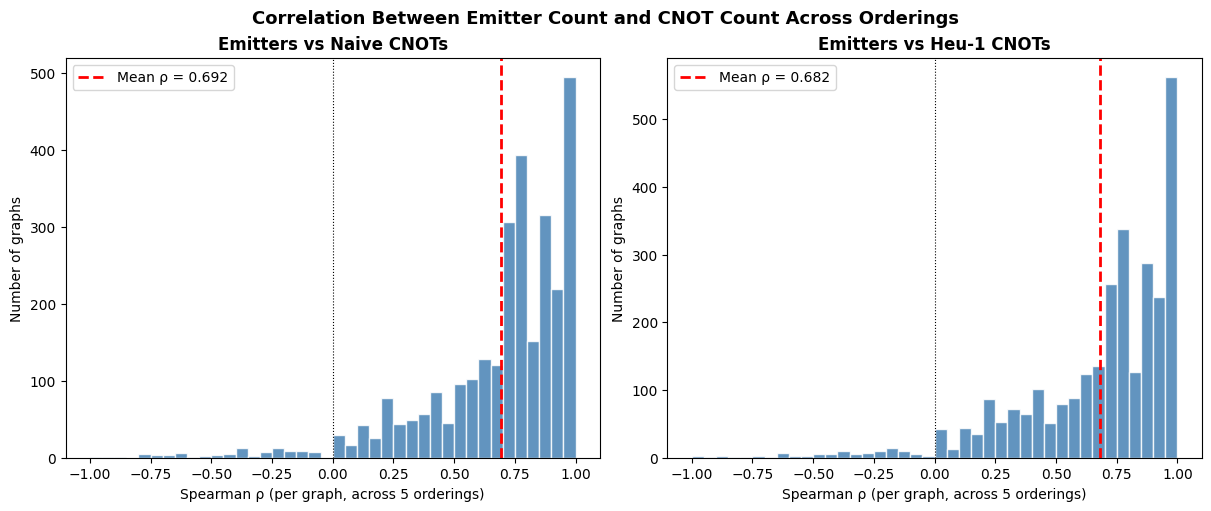


Naive CNOTs:  mean ρ = 0.692  (median = 0.791,  n = 2897 graphs)
Heu-1 CNOTs:  mean ρ = 0.682  (median = 0.791,  n = 2898 graphs)


In [25]:
# ═══════════════════════════════════════════════════════════════════
# PLOT F — Emitter vs CNOT correlation across orderings per graph
# ═══════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

em_cols    = [f'takou_naive_em_{sfx}' for sfx in ALGO_SUFFIXES]
cn_naive   = [f'takou_naive_cnots_{sfx}' for sfx in ALGO_SUFFIXES]
cn_heu1    = [f'takou_heu1_cnots_{sfx}' for sfx in ALGO_SUFFIXES]

rho_naive, rho_heu1 = [], []
for _, row in merged.iterrows():
    em_vals = row[em_cols].values.astype(float)
    cn_n    = row[cn_naive].values.astype(float)
    cn_h    = row[cn_heu1].values.astype(float)

    if np.all(np.isfinite(em_vals)) and np.all(np.isfinite(cn_n)):
        if np.std(em_vals) > 0 and np.std(cn_n) > 0:
            rho_naive.append(spearmanr(em_vals, cn_n).statistic)
    if np.all(np.isfinite(em_vals)) and np.all(np.isfinite(cn_h)):
        if np.std(em_vals) > 0 and np.std(cn_h) > 0:
            rho_heu1.append(spearmanr(em_vals, cn_h).statistic)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, rho_vals, title in zip(axes,
                                [rho_naive, rho_heu1],
                                ['Emitters vs Naive CNOTs', 'Emitters vs Heu-1 CNOTs']):
    ax.hist(rho_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    mean_rho = np.mean(rho_vals)
    ax.axvline(mean_rho, color='red', linewidth=2, linestyle='--',
               label=f'Mean ρ = {mean_rho:.3f}')
    ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Spearman ρ (per graph, across 5 orderings)')
    ax.set_ylabel('Number of graphs')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle('Correlation Between Emitter Count and CNOT Count Across Orderings',
             fontsize=13, fontweight='bold')
plt.show()

print(f"\nNaive CNOTs:  mean ρ = {np.mean(rho_naive):.3f}  "
      f"(median = {np.median(rho_naive):.3f},  n = {len(rho_naive)} graphs)")
print(f"Heu-1 CNOTs:  mean ρ = {np.mean(rho_heu1):.3f}  "
      f"(median = {np.median(rho_heu1):.3f},  n = {len(rho_heu1)} graphs)")

### Plot G — Scatter: Emitter Reduction vs CNOT Reduction

Each dot represents one **(graph × algorithm)** pair. The x-axis is the % change in emitters (vs random ordering) and the y-axis is the % change in CNOTs (vs random). Two panels: Naive CNOTs (left) and Heu-1 CNOTs (right). Dots are coloured by algorithm.

**How to read the quadrants:**
- **Bottom-left (fewer emitters, fewer CNOTs):** The ideal region — the ordering improves both metrics. A dense cloud here means the two objectives are aligned.
- **Top-left (fewer emitters, more CNOTs):** The trade-off region — the ordering saves emitters but costs extra CNOTs.
- **Bottom-right (more emitters, fewer CNOTs):** The opposite trade-off — rare if our algorithms reliably reduce emitters.
- **Top-right (more emitters, more CNOTs):** Worse on both counts — ideally empty.

**What to look for:**
- A **tight diagonal cloud** running from upper-right to lower-left indicates a strong positive correlation — emitter savings translate proportionally into CNOT savings.
- A **horizontal spread** (dots scattered left-right at similar y) means CNOT counts are largely independent of emitter counts.
- If the Heu-1 panel shows dots **compressed toward y = 0** compared to Naive, it means gate optimisation flattens CNOT differences across orderings, reducing the impact of the ordering choice on the final gate count.

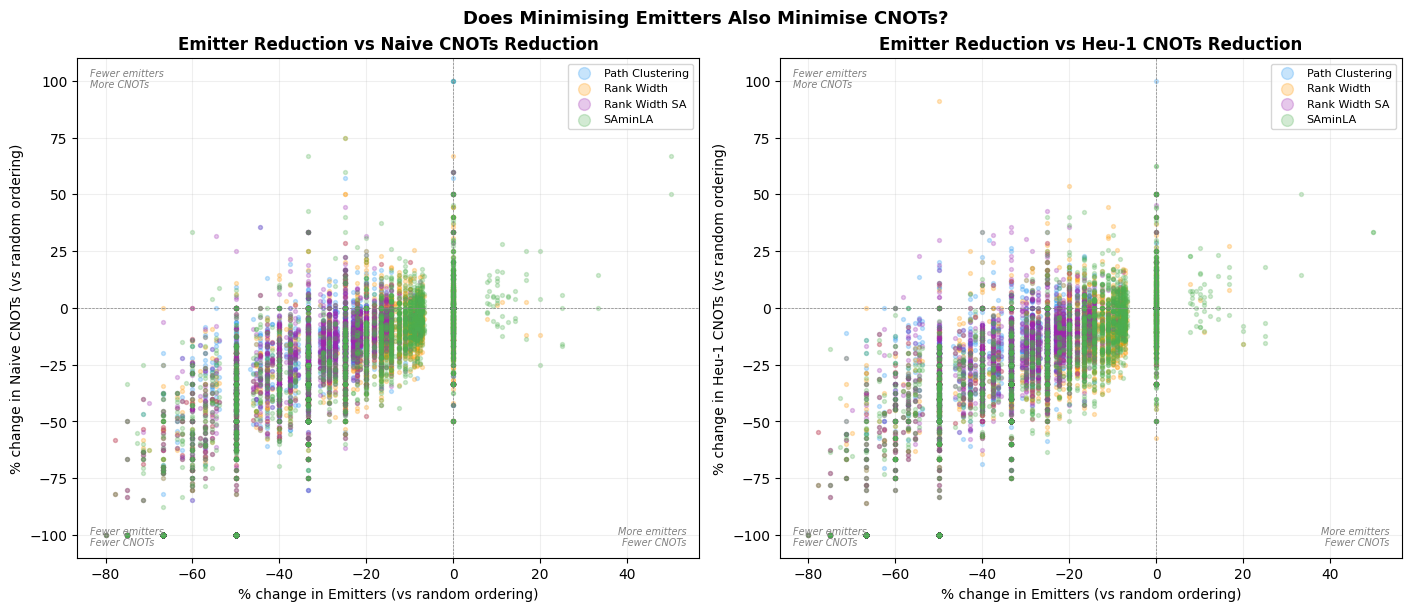

In [26]:
# ═══════════════════════════════════════════════════════════════════
# PLOT G — Scatter: % emitter reduction vs % CNOT reduction
#           Each dot = one (graph × algorithm) pair, coloured by algorithm.
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, cnot_tmpl, cnot_label in zip(
    axes,
    ['takou_naive_cnots_{}', 'takou_heu1_cnots_{}'],
    ['Naive CNOTs', 'Heu-1 CNOTs'],
):
    for sfx, label, color in zip(OPT_SUFFIXES, OPT_LABELS, OPT_COLORS):
        em_pct = f'pct_takou_naive_em_{sfx}'
        cn_pct = f'pct_{cnot_tmpl.format(sfx)}'
        valid = merged[[em_pct, cn_pct]].dropna()
        ax.scatter(valid[em_pct], valid[cn_pct], s=8, alpha=0.25,
                   color=color, label=label, rasterized=True)

    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('% change in Emitters (vs random ordering)')
    ax.set_ylabel(f'% change in {cnot_label} (vs random ordering)')
    ax.set_title(f'Emitter Reduction vs {cnot_label} Reduction', fontweight='bold')
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(True, alpha=0.2)

    # Quadrant annotations
    ax.text(0.02, 0.98, 'Fewer emitters\nMore CNOTs', transform=ax.transAxes,
            fontsize=7, va='top', ha='left', color='grey', style='italic')
    ax.text(0.02, 0.02, 'Fewer emitters\nFewer CNOTs', transform=ax.transAxes,
            fontsize=7, va='bottom', ha='left', color='grey', style='italic')
    ax.text(0.98, 0.02, 'More emitters\nFewer CNOTs', transform=ax.transAxes,
            fontsize=7, va='bottom', ha='right', color='grey', style='italic')

fig.suptitle('Does Minimising Emitters Also Minimise CNOTs?',
             fontsize=13, fontweight='bold')
plt.show()